# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 6</span>


In Statistical Mechanics the one-dimensional (1D) Ising Model is exactly resoluble. The Hamiltonian for a system of N spins with nearest neighbors interaction is given by (in the following I will assume units such that $\mu_B=1$ and $k_B=1$):

$$
H = 
-J\sum_{i=1}^N s_i s_{i+1}
-\frac{h}{2}\sum_{i=1}^N (s_i + s_{i+1}) 
$$

where $\{ s_i \}_{i=1,N}$ are spin variables taking values in $\{-1;1\}$, $J>0$ (ferromagnetic model),and with the assumption $s_{N+1} = s_{1}$.

The partition function for $N$ spins, $Z$, can be exactly computed and it turns out to be:

$$
Z=\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \lambda_1^N + \lambda_2^N
$$

where
$\lambda_{1,2} = 
e^{\beta J} 
\cosh (\beta h) \pm \left[ e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J) \right]^{1/2}$, 
and where $\beta=\frac{1}{k_b T} = \frac{1}{T}$.
Once the partition function has been computed, the Helmholtz free energy is readly obtained as $A = -k_B T \ln Z$. All the thermodynamic quantities of interest can be deduced from $A$ or, equivalently, from $Z$:

- the **Internal Energy** per spin (with $h=0$):

$$
\frac{U(N,T)}{N} = \frac{\langle H \rangle}{N}
= \frac{1}{N} \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}
= -\frac{1}{N}\frac{\partial \ln Z}{\partial \beta}
\underset{h=0}= -J \tanh (\beta J) \Biggl( \frac{1 + \tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)} \Biggl)
$$

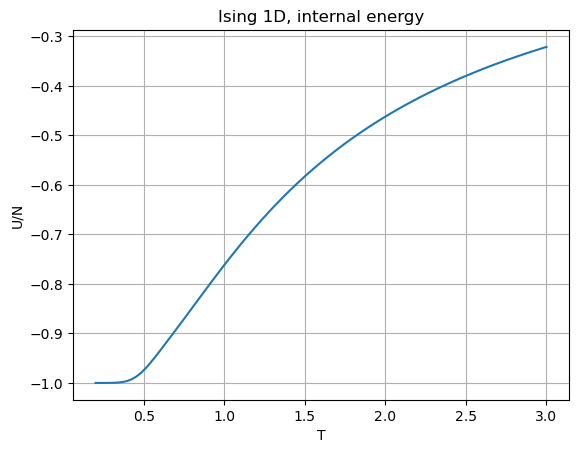

In [17]:
import numpy as np
import matplotlib.pyplot as plt
points=100
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )
plt.plot(T, e)
plt.title('Ising 1D, internal energy')
plt.xlabel('T')
plt.ylabel('U/N')
plt.grid()
plt.show()

- the **Heat Capacity** (with $h=0$):

$$
C(N,T) = \frac{\partial U(N,T)}{\partial T}
= \frac{\partial \beta}{\partial T}\frac{\partial U}{\partial \beta}
= -k_B\beta^2 \frac{\partial}{\partial \beta} \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z} \right] = \\
= -k_B\beta^2 \left[ -\sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} + \sum_{\{ s_i \}} H \exp \left( -\beta H\right)\frac{\partial Z^{-1}}{\partial \beta} \right] = \\
= k_B\beta^2 \left\{ \sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} + \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}\right]\frac{1}{Z}\frac{\partial Z}{\partial \beta} \right\} =\\
= k_B\beta^2 \left\{ \sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} - \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}\right]^2 \right\} =
k_B\beta^2 \left(\langle H^2 \rangle -\langle H \rangle^2 \right)
$$

$$
\frac{C(N,T)}{N} = \frac{1}{N}\frac{\partial U(N,T)}{\partial T} =\\
\underset{h=0}= 
k_B (\beta J)^2 \left\{ 1+\tanh^N (\beta J)+(N-1)\tanh^2 (\beta J)+(N-1)\frac{\tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)}
- N \left[ \frac{\tanh (\beta J) + \tanh^{N-1} (\beta J)}{1+\tanh^N (\beta J)} \right]^2 \right\}
$$

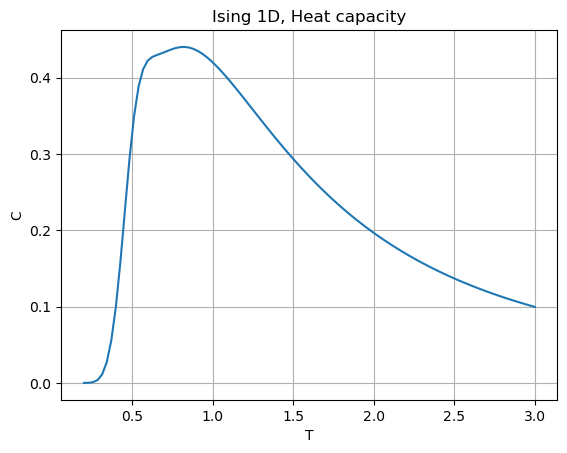

In [18]:
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
plt.plot(T, heat)
plt.title('Ising 1D, Heat capacity')
plt.xlabel('T')
plt.ylabel('C')
plt.grid()
plt.show()

- The **magnetization** (with $h \not= 0$):

Note that with $h=0$ the magnetization $M(N,T,h=0)=\langle \sum_{i=1,N}s_i \rangle =0$ because in 1D we cannot have a (ferromagnetic) phase transition in absence of an external magnetic field.

$$
M(N,T,h) = -\frac{\partial A}{\partial h} = k_B T \frac{\partial \ln Z}{\partial h} =
\frac{1}{\beta} \frac{1}{Z}\frac{\partial}{\partial h}\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right] \frac{\exp \left( -\beta H\right)}{Z} = \left\langle \sum_{i=1,N}s_i \right\rangle
$$

The exact formula from $M(N,T,h) = k_B T \dfrac{\partial \ln Z}{\partial h}$ is:
$$
\frac{M(N,T,h)}{N}=\frac{e^{\beta J}\; \sinh(\beta h)}{Z} \; \Bigl[\lambda_1^{N-1}\cdot \Bigl(1+\frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J)}}\Bigr) + \lambda_2^{N-1}\cdot \Bigl(1-\frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J)}}\Bigr)\Bigr]
$$

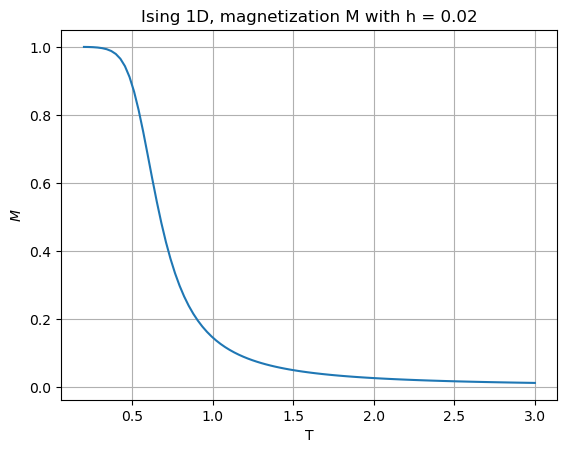

In [19]:
h=0.02 #external field
b = 1/T

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
plt.plot(T, M)
plt.title('Ising 1D, magnetization M with h = 0.02')
plt.xlabel('T')
plt.ylabel('$M$')
plt.grid()
plt.show()

- The **magnetic susceptibility** (with $h=0$):

$$
\chi(N,T) = \frac{\partial M}{\partial h} = 
\frac{\partial}{\partial h}\sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right] \frac{\exp \left( -\beta H\right)}{Z} =\\
= \beta\sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right]^2 \frac{\exp \left( -\beta H\right)}{Z}
-\sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right] \frac{\exp \left( -\beta H\right)}{Z}
\frac{1}{Z}\frac{\partial Z}{\partial h} = 
\beta \left[ \left\langle \left( \sum_{i=1,N}s_i \right)^2 \right\rangle - \left\langle \sum_{i=1,N}s_i \right\rangle^2 \right] = \\
\underset{h=0}= \beta \left[ \left\langle \left( \sum_{i=1,N}s_i \right)^2 \right\rangle \right] = \beta e^{2\beta J} \Biggl( \frac{1-\tanh^N (\beta J)}{1+\tanh^N (\beta J)} \Biggl)
$$

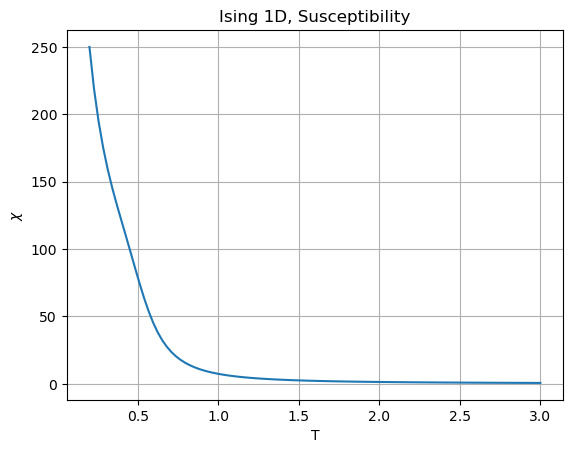

In [20]:
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)
plt.plot(T, X)
plt.title('Ising 1D, Susceptibility')
plt.xlabel('T')
plt.ylabel('$\chi$')
plt.grid()
plt.show()

### Exercise 06.1

Complete the NSL_simulator code to simulate a 1D Ising model with the Gibbs sampling algorithm (the Metropolis algorithm is already implemented) to sample the Boltzmann's weight $p(\{ s_i \}) = \exp(-\beta H)/Z$. Verify the possibility to restart from a previous spin configuration.

The code already computes the internal energy: $U(N,T) = \langle H \rangle$. Add the calculation of $C(N,T)$, $\chi(N,T)$, $M(N,T,h)$ and compute:
1. $U(N,T) = \langle H \rangle_{h=0}$
2. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 
3. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
4. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

as a function of $T$ in the range $\left[0.5;2.0\right]$ for a system of $N=50$ spins with $J=1$.

As usual, use data blocking and give an estimate of the statistical uncertainties.

- <span style="color:red">Show pictures of your estimations of $U(N,T)$, $C(N,T)$, $\chi(N,T)$, $M(N,T,h=0.02)$ and their uncertainties</span> obtained with a large number of *MC steps* (e.g. $M\ge 10^5$) compared with the exact curves. In the same picture show your results obtained with <span style="color:blue">both sampling methods, Metropolis and Gibbs</span>.

A Monte Carlo step will consist in trying to flip one time all the spins of the system. Do not forget to equilibrate your simulations and to use blocking average with blocks large enough.

## Implementazione algoritmo di Gibbs

L'algoritmo di Gibbs è un caso particolare dell'algoritmo di Metropolis in cui la mossa proposta viene sempre accettata.
In particolare l'algoritmo di Gibbs rimpiazza ogni componente con il valore estratto dalla sua distribuzione condizionale dei valori attuali di tutte le altre componenti. 

Riguardo il modello di ising 1D l'algoritmo di Gibbs esegue le seguenti operazioni:
- Calcolo la differenza di energia tra uno stato con spin up e uno con spin down: $\Delta E = E(s_i = +1) - E(s_i = -1) = - 2 \, [J(s_{i-1} + s_{i+1}) + H]$
- Calcolo la probalbilità condizionata che lo spin $i$ si posizioni a $+1$, indipendentemente da quale fosse il suo stato precedente. Poichè nel modello di Ising la configurazione degli spin del sistema deve seguire la distribuzione di Boltzmann la calcolo come $p = \frac{1}{1 + e^{\beta\,\Delta\,E}}$
- Estraggo un numero casuale tra $0$ e $1$ e se il numero casuale è minore di $p$ lo spin viene impostato a $+1$, altrimenti lo spin viene impostato a $-1$.

## Protocollo di Simulazione

Per monitorare le proprietà termodinamiche del modello di Ising 1D nell'intervallo di temperature richieste ($T \in [0.5, 2.0]$) è stato scelto di partire con una **fase di equilibrazione** (che caratterizzerà ogni simulazione successiva a temperature differenti). In seguito alla fase di equilibrazione il sistema evolve a una data temperatura utilizzando la tecnica del **datablocking**. Sono stati scegli **30 blocchi** da **200.000 simulazioni**.
In seguito, salvati i dati delle quantità termodinamiche finali (sempre alla stessa temperatura) viene registrata la configurazione di spin del sistema.
Tale configurazione viene presa come configurazione di spin di input alla fase di equilibrazione della simulazione alla temperatura successiva. Tale temperatura è $T_{i + 1} = T_{i} - 0.1$. Questo ciclo viene ripetuto finchè non viene raggiunta la temperatura finale $T = 0.5$


## Fase di equilibrazione

Il sistema per ogni temperatura è stato sottoposto a una **fase di equilibrazione** di **10.000 steps**. In questa fase il sistema evolve termodinamicamente modificando la configurazione degli spin fino al raggiungimento della stabiizzazione delle quantità termodinamiche.
Tuttavia è bene sottolineare che nessuno di questi passi transitori va a "sporcare" le medie statistiche dei blocchi, che inizieranno ad accumulare dati solo nel ciclo successivo.

Di seguito un esempio di una fase di equilibrazione dell'energia interna eseguita a $T = 1$

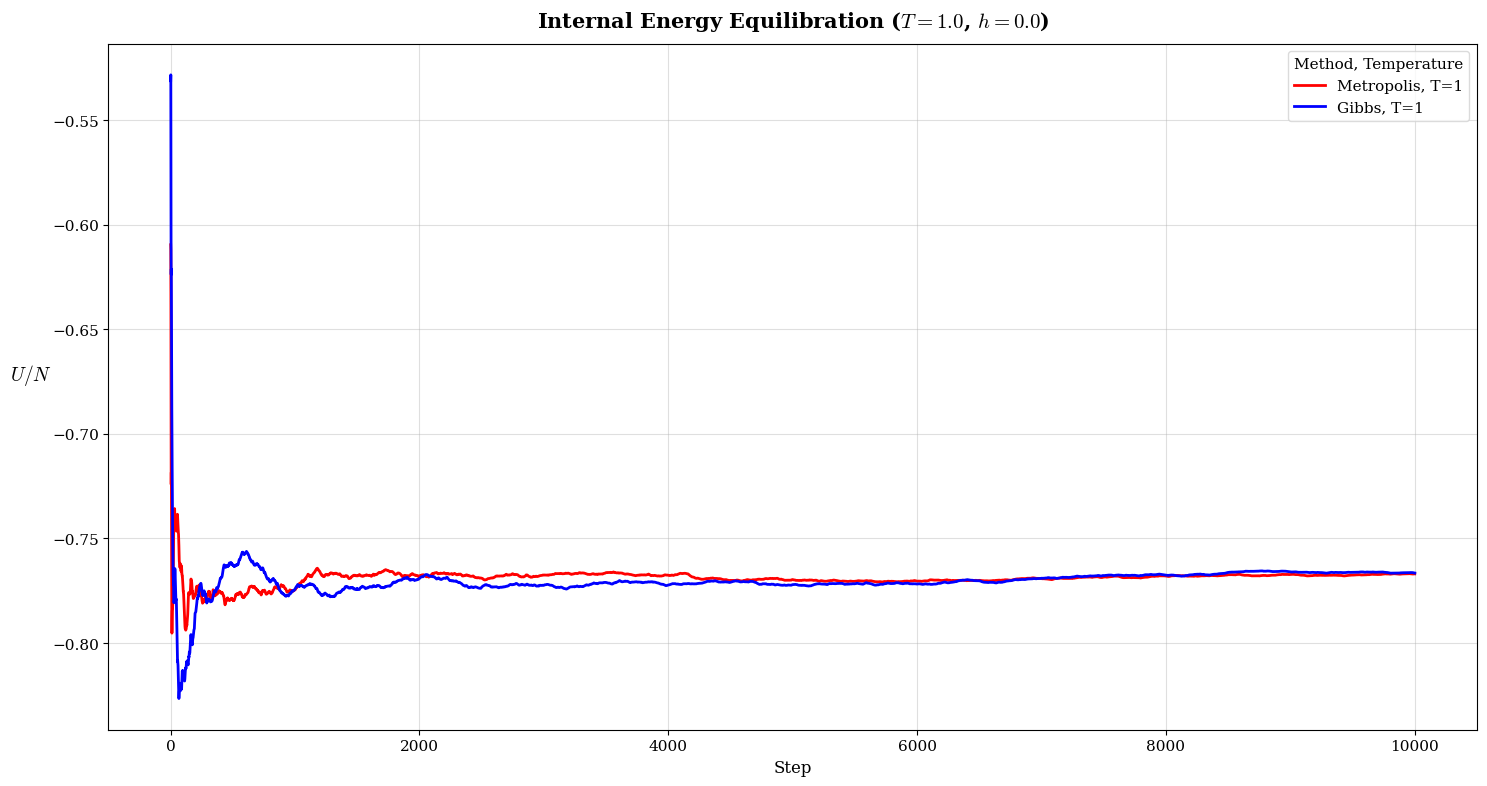

In [3]:
import numpy as np
import matplotlib.pyplot as plt

config = {
    'filename': 'total_energy.dat',
    'title': 'Internal Energy Equilibration ($T=1.0$, $h=0.0$)',
    'ylabel': '$U/N$'
}

folders = {'Metro': 'Equil_Metro', 'Gibbs': 'Equil_Gibbs'}

plt.rcParams.update({'font.size': 11, 'font.family': 'serif', 'mathtext.fontset': 'cm'})

curve_styles = {
    'Metro': {'color': 'red', 'label': 'Metropolis'},
    'Gibbs': {'color': 'blue', 'label': 'Gibbs'}
}

data = {'Metro': None, 'Gibbs': None}

for name, path in folders.items():
    file_path = f"{path}/{config['filename']}"
    try:
        loaded = np.loadtxt(file_path, usecols=2)
        data[name] = np.atleast_1d(loaded)
    except FileNotFoundError:
        print(f"Warning: File {file_path} non trovato.")
        data[name] = np.array([])

if len(data['Metro']) > 0 or len(data['Gibbs']) > 0:
    
    max_len = len(data['Metro']) if len(data['Metro']) > 0 else len(data['Gibbs'])
    steps = np.arange(1, max_len + 1)
    
    plt.figure(figsize=(15, 8))
    
    for name in ['Metro', 'Gibbs']:
        if len(data[name]) > 0:
            y_values = data[name][:max_len]
            x_values = steps[:len(y_values)]
            plt.plot(x_values, y_values, color=curve_styles[name]['color'], 
                     label=f"{curve_styles[name]['label']}, T=1", linewidth=2)
        
    plt.title(config['title'], fontweight='bold', fontsize=15, pad=12)
    plt.xlabel("Step", fontsize=12)
    plt.ylabel(config['ylabel'], fontsize=14, rotation=0, labelpad=15)
    plt.grid(True, linestyle='-', alpha=0.4)
    plt.legend(title="Method, Temperature", loc='best', frameon=True, edgecolor='lightgray')
    plt.tight_layout()
    plt.show()

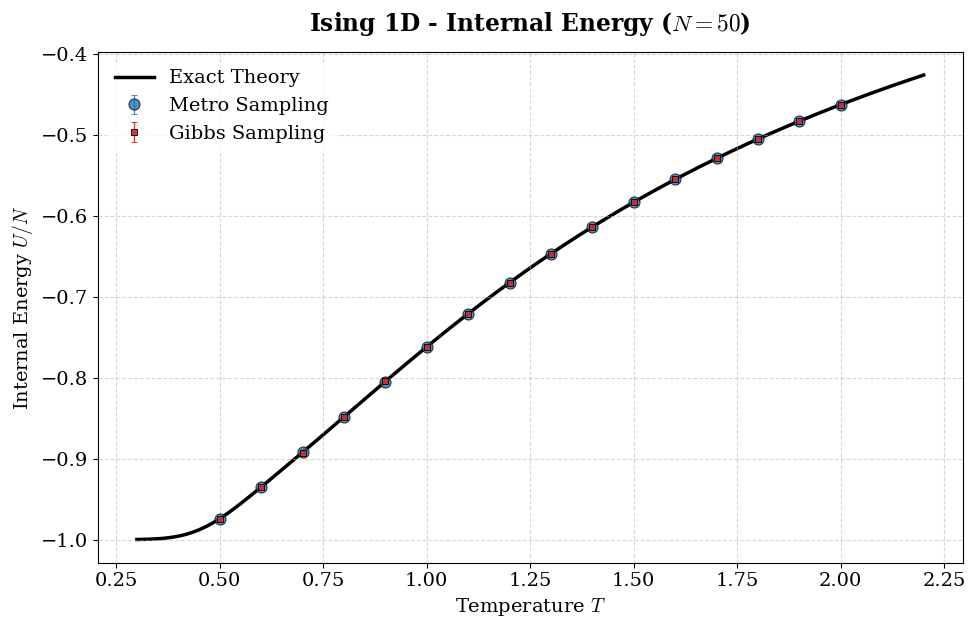

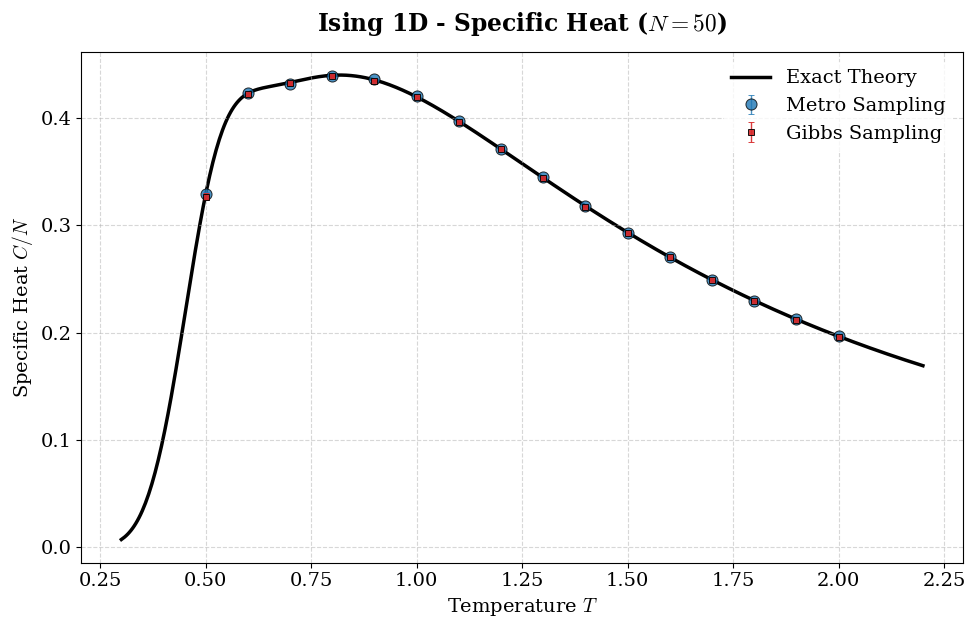

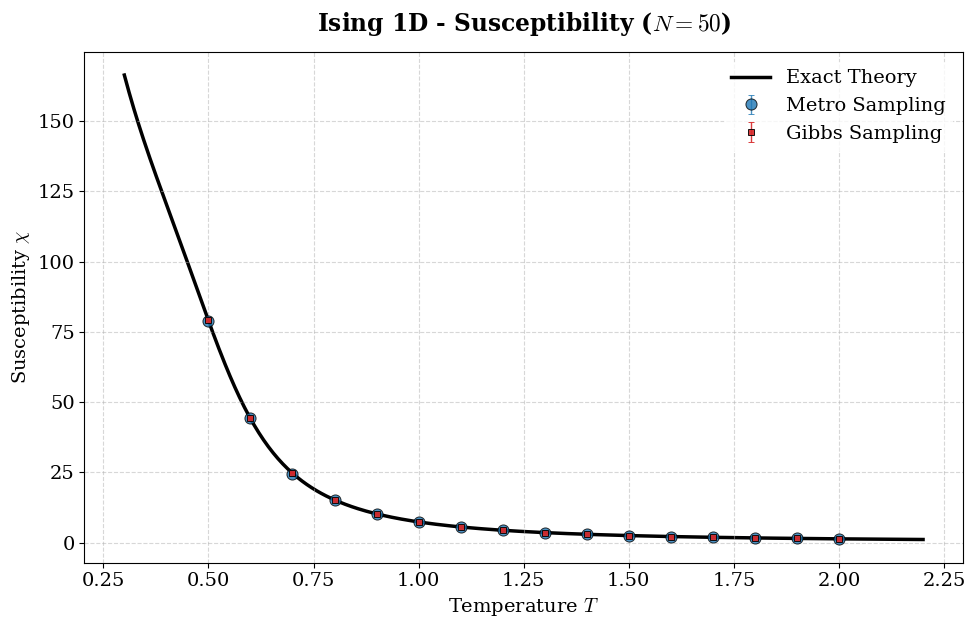

In [4]:
import numpy as np
import matplotlib.pyplot as plt

N = 50
J = 1.0
T_sim = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])

T_th = np.linspace(0.3, 2.2, 500)
beta_th = 1.0 / T_th
th = np.tanh(J / T_th)
thN = th**N
ch = 1.0 / th

e_th = -J * (th + ch * thN) / (1.0 + thN)
heat_th = (beta_th * J)**2 * ((1 + thN + (N - 1) * th**2 + (N - 1) * ch**2 * thN) / (1 + thN) - N * ((th + ch * thN) / (1 + thN))**2)
chi_th = beta_th * np.exp(2 * beta_th * J) * (1 - thN) / (1 + thN)

folders = {'Metro': 'OUTPUT_Metro', 'Gibbs': 'OUTPUT_Gibbs'}
data = {folder: {key: {'val': [], 'err': []} for key in ['U', 'C', 'CHI']} for folder in folders}

for name, path in folders.items():
    for t in T_sim:
        t_str = f"{t:.2f}".replace('.', '_')
        u_row = np.loadtxt(f"{path}/total_energy_{t_str}.dat")[-1]
        c_row = np.loadtxt(f"{path}/specific_heat_{t_str}.dat")[-1]
        chi_row = np.loadtxt(f"{path}/susceptibility_{t_str}.dat")[-1]
        
        data[name]['U']['val'].append(u_row[2]); data[name]['U']['err'].append(u_row[3])
        data[name]['C']['val'].append(c_row[2]); data[name]['C']['err'].append(c_row[3])
        data[name]['CHI']['val'].append(chi_row[2]); data[name]['CHI']['err'].append(chi_row[3])

plot_configs = [
    {'key': 'U',   'th_y': e_th,    'title': 'Internal Energy', 'ylabel': 'Internal Energy $U/N$'},
    {'key': 'C',   'th_y': heat_th, 'title': 'Specific Heat',   'ylabel': 'Specific Heat $C/N$'},
    {'key': 'CHI', 'th_y': chi_th,  'title': 'Susceptibility',  'ylabel': 'Susceptibility $\chi$'}
]

plt.rcParams.update({'font.size': 14, 'font.family': 'serif', 'mathtext.fontset': 'cm'})

styles = {
    'Metro':  {'color': '#1f77b4', 'marker': 'o', 'size': 8, 'alpha': 0.8},
    'Gibbs':  {'color': '#d62728', 'marker': 's', 'size': 4, 'alpha': 0.9}
}

for config in plot_configs:
    plt.figure(figsize=(10, 6.5))
    
    plt.plot(T_th, config['th_y'], label='Exact Theory', color='black', 
             linestyle='-', linewidth=2.5, zorder=1)
    
    for name, s in styles.items():
        plt.errorbar(T_sim, data[name][config['key']]['val'], 
                     yerr=data[name][config['key']]['err'], 
                     fmt=s['marker'], 
                     color=s['color'], 
                     markeredgecolor='black', 
                     markeredgewidth=0.7,
                     markersize=s['size'], 
                     alpha=s['alpha'], 
                     capsize=2.5, 
                     elinewidth=1.0, 
                     label=f'{name} Sampling', 
                     zorder=2 if name == 'Metro' else 3,
                     linestyle='none')
    
    plt.title(f"Ising 1D - {config['title']} ($N=50$)", fontweight='bold', pad=15)
    plt.xlabel('Temperature $T$')
    plt.ylabel(config['ylabel'])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(frameon=True, loc='best', edgecolor='none')
    
    plt.tight_layout()
    plt.show()

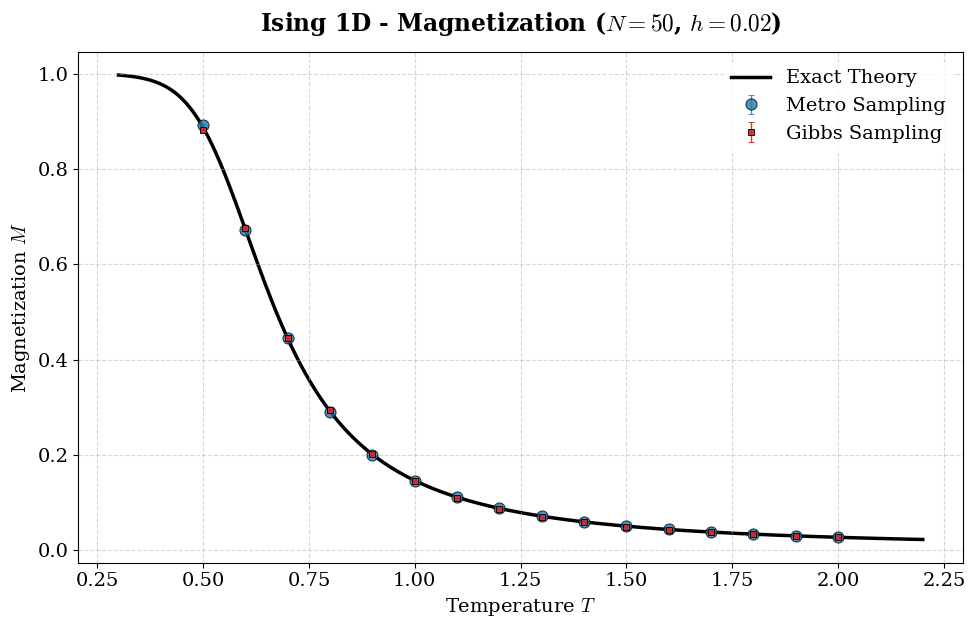

In [5]:
import numpy as np
import matplotlib.pyplot as plt

N = 50
J = 1.0
h = 0.02
T_sim = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])
T_th = np.linspace(0.3, 2.2, 500)
beta_th = 1.0 / T_th

l1 = np.exp(beta_th * J) * np.cosh(beta_th * h) + np.sqrt(np.exp(2 * beta_th * J) * np.cosh(beta_th * h)**2 - 2 * np.sinh(2 * beta_th * J))
l2 = np.exp(beta_th * J) * np.cosh(beta_th * h) - np.sqrt(np.exp(2 * beta_th * J) * np.cosh(beta_th * h)**2 - 2 * np.sinh(2 * beta_th * J))
Z_th = l1**N + l2**N
m_th = (np.exp(beta_th * J) * np.sinh(beta_th * h) * (l1**(N - 1) * (1 + np.exp(beta_th * J) * np.cosh(beta_th * h) / np.sqrt(np.exp(2 * beta_th * J) * np.cosh(beta_th * h)**2 - 2 * np.sinh(2 * beta_th * J))) + l2**(N - 1) * (1 - np.exp(beta_th * J) * np.cosh(beta_th * h) / np.sqrt(np.exp(2 * beta_th * J) * np.cosh(beta_th * h)**2 - 2 * np.sinh(2 * beta_th * J))))) / Z_th

folders = {'Metro': 'Mag_Metro', 'Gibbs': 'Mag_Gibbs'}
data = {folder: {'M': {'val': [], 'err': []}} for folder in folders}

for name, path in folders.items():
    for t in T_sim:
        t_str = f"{t:.2f}".replace('.', '_')
        m_row = np.loadtxt(f"{path}/magnetization_{t_str}.dat")[-1]
        
        data[name]['M']['val'].append(m_row[2])
        data[name]['M']['err'].append(m_row[3])

plt.rcParams.update({'font.size': 14, 'font.family': 'serif', 'mathtext.fontset': 'cm'})

styles = {
    'Metro':  {'color': '#1f77b4', 'marker': 'o', 'size': 8, 'alpha': 0.8},
    'Gibbs':  {'color': '#d62728', 'marker': 's', 'size': 4, 'alpha': 0.9}
}

plt.figure(figsize=(10, 6.5))
plt.plot(T_th, m_th, label='Exact Theory', color='black', 
         linestyle='-', linewidth=2.5, zorder=1)

for name, s in styles.items():
    plt.errorbar(T_sim, data[name]['M']['val'], 
                 yerr=data[name]['M']['err'], 
                 fmt=s['marker'], 
                 color=s['color'], 
                 markeredgecolor='black', 
                 markeredgewidth=0.7,
                 markersize=s['size'], 
                 alpha=s['alpha'], 
                 capsize=2.5, 
                 elinewidth=1.0, 
                 label=f'{name} Sampling', 
                 zorder=2 if name == 'Metro' else 3,
                 linestyle='none')

plt.title(f"Ising 1D - Magnetization ($N=50$, $h=0.02$)", fontweight='bold', pad=15)
plt.xlabel('Temperature $T$')
plt.ylabel('Magnetization $M$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, loc='best', edgecolor='none')
plt.tight_layout()
plt.show()

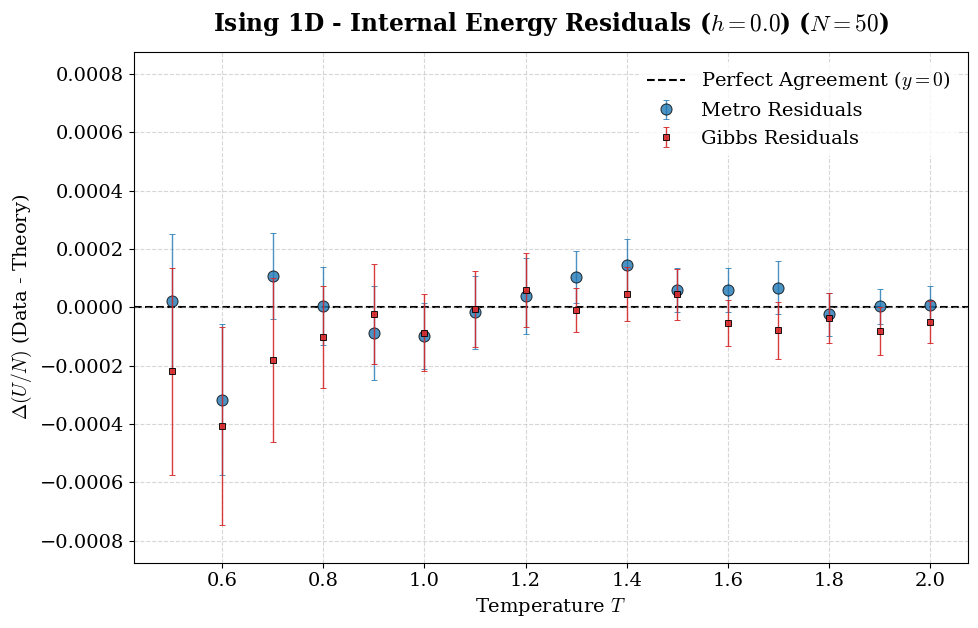

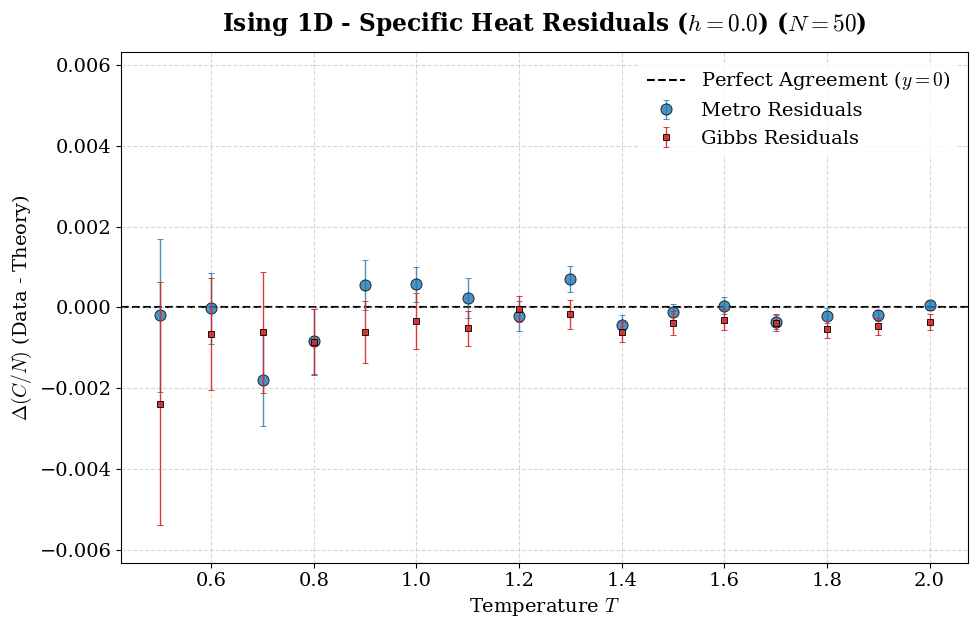

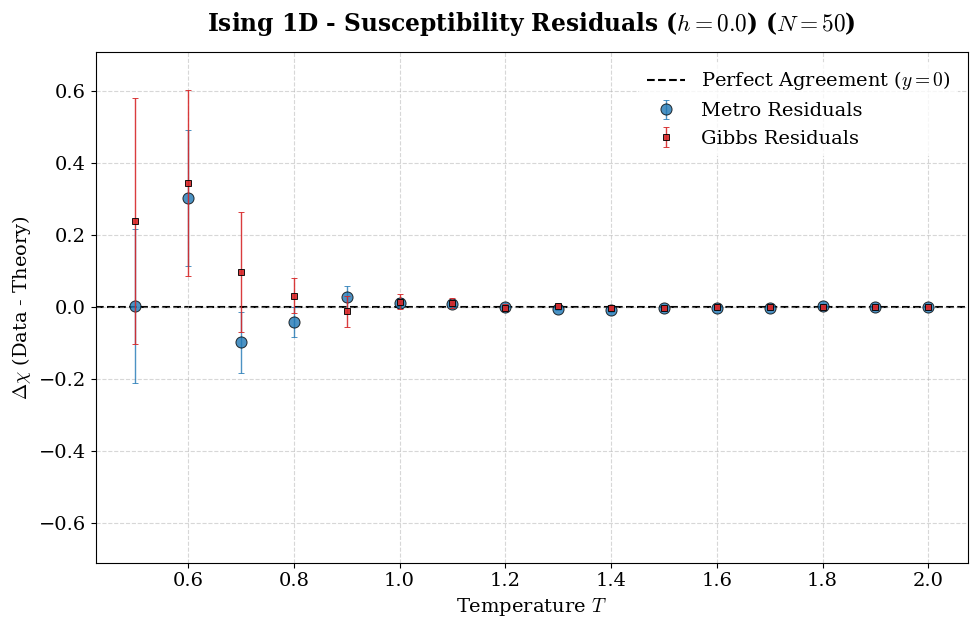

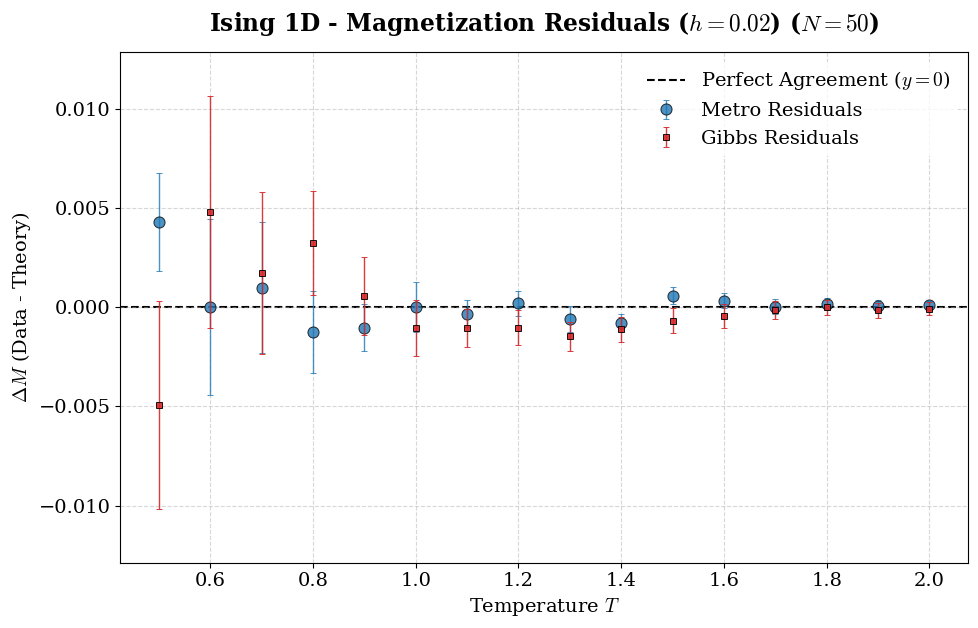

In [6]:
import numpy as np
import matplotlib.pyplot as plt

N = 50
J = 1.0
h = 0.02
T_sim = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])

beta_sim = 1.0 / T_sim
th_sim = np.tanh(J / T_sim)
thN_sim = th_sim**N
ch_sim = 1.0 / th_sim
e_th_sim = -J * (th_sim + ch_sim * thN_sim) / (1.0 + thN_sim)
heat_th_sim = (beta_sim * J)**2 * ((1 + thN_sim + (N - 1) * th_sim**2 + (N - 1) * ch_sim**2 * thN_sim) / (1 + thN_sim) - N * ((th_sim + ch_sim * thN_sim) / (1 + thN_sim))**2)
chi_th_sim = beta_sim * np.exp(2 * beta_sim * J) * (1 - thN_sim) / (1 + thN_sim)
l1 = np.exp(beta_sim * J) * np.cosh(beta_sim * h) + np.sqrt(np.exp(2 * beta_sim * J) * np.cosh(beta_sim * h)**2 - 2 * np.sinh(2 * beta_sim * J))
l2 = np.exp(beta_sim * J) * np.cosh(beta_sim * h) - np.sqrt(np.exp(2 * beta_sim * J) * np.cosh(beta_sim * h)**2 - 2 * np.sinh(2 * beta_sim * J))
Z_th = l1**N + l2**N
m_th_sim = (np.exp(beta_sim * J) * np.sinh(beta_sim * h) * (l1**(N - 1) * (1 + np.exp(beta_sim * J) * np.cosh(beta_sim * h) / np.sqrt(np.exp(2 * beta_sim * J) * np.cosh(beta_sim * h)**2 - 2 * np.sinh(2 * beta_sim * J))) + l2**(N - 1) * (1 - np.exp(beta_sim * J) * np.cosh(beta_sim * h) / np.sqrt(np.exp(2 * beta_sim * J) * np.cosh(beta_sim * h)**2 - 2 * np.sinh(2 * beta_sim * J))))) / Z_th

th_values = {
    'U': e_th_sim,
    'C': heat_th_sim,
    'CHI': chi_th_sim,
    'M': m_th_sim
}

folders_properties = {'Metro': 'OUTPUT_Metro', 'Gibbs': 'OUTPUT_Gibbs'}
folders_magnetization = {'Metro': 'Mag_Metro', 'Gibbs': 'Mag_Gibbs'}

data = {alg: {key: {'val': [], 'err': []} for key in ['U', 'C', 'CHI', 'M']} for alg in ['Metro', 'Gibbs']}

for name in ['Metro', 'Gibbs']:
    path_prop = folders_properties[name]
    path_mag = folders_magnetization[name]
    
    for t in T_sim:
        t_str = f"{t:.2f}".replace('.', '_')
        
        u_row = np.loadtxt(f"{path_prop}/total_energy_{t_str}.dat")[-1]
        c_row = np.loadtxt(f"{path_prop}/specific_heat_{t_str}.dat")[-1]
        chi_row = np.loadtxt(f"{path_prop}/susceptibility_{t_str}.dat")[-1]
        m_row = np.loadtxt(f"{path_mag}/magnetization_{t_str}.dat")[-1]
        
        data[name]['U']['val'].append(u_row[2]); data[name]['U']['err'].append(u_row[3])
        data[name]['C']['val'].append(c_row[2]); data[name]['C']['err'].append(c_row[3])
        data[name]['CHI']['val'].append(chi_row[2]); data[name]['CHI']['err'].append(chi_row[3])
        data[name]['M']['val'].append(m_row[2]); data[name]['M']['err'].append(m_row[3])

plot_configs = [
    {'key': 'U',   'title': 'Internal Energy Residuals ($h=0.0$)', 'ylabel': '$\Delta (U/N)$ (Data - Theory)'},
    {'key': 'C',   'title': 'Specific Heat Residuals ($h=0.0$)',   'ylabel': '$\Delta (C/N)$ (Data - Theory)'},
    {'key': 'CHI', 'title': 'Susceptibility Residuals ($h=0.0$)',  'ylabel': '$\Delta \chi$ (Data - Theory)'},
    {'key': 'M',   'title': 'Magnetization Residuals ($h=0.02$)',  'ylabel': '$\Delta M$ (Data - Theory)'}
]

plt.rcParams.update({'font.size': 14, 'font.family': 'serif', 'mathtext.fontset': 'cm'})

styles = {
    'Metro':  {'color': '#1f77b4', 'marker': 'o', 'size': 8, 'alpha': 0.8},
    'Gibbs':  {'color': '#d62728', 'marker': 's', 'size': 4, 'alpha': 0.9}
}

for config in plot_configs:
    plt.figure(figsize=(10, 6.5))
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Perfect Agreement ($y=0$)', zorder=1)
    for name, s in styles.items():
        residuals = np.array(data[name][config['key']]['val']) - th_values[config['key']]
        errors = data[name][config['key']]['err']
        plt.errorbar(T_sim, residuals, 
                     yerr=errors, 
                     fmt=s['marker'], 
                     color=s['color'], 
                     markeredgecolor='black', 
                     markeredgewidth=0.7,
                     markersize=s['size'], 
                     alpha=s['alpha'], 
                     capsize=2.5, 
                     elinewidth=1.0, 
                     label=f'{name} Residuals', 
                     zorder=2 if name == 'Metro' else 3,
                     linestyle='none')
    plt.title(f"Ising 1D - {config['title']} ($N=50$)", fontweight='bold', pad=15)
    plt.xlabel('Temperature $T$')
    plt.ylabel(config['ylabel'])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(frameon=True, loc='best', edgecolor='none')
    y_lims = plt.gca().get_ylim()
    bound = max(abs(y_lims[0]), abs(y_lims[1]))
    plt.ylim(-bound * 1.1, bound * 1.1)
    plt.tight_layout()
    plt.show()